# Experimento 5: Class Weights

**Punto de partida:** Experimento 3 (PubMedBERT + typed markers + neg_ratio 1:1) -> Macro F1 = 0.8430

**Hipotesis:** Las clases minoritarias (ALTERNATIVE_NAME F1=0.50, APPLIED_TO F1=0.53) tienen muy pocos ejemplos (95 y 43). Con CrossEntropyLoss normal, cada ejemplo contribuye igual a la loss, asi que las clases con 743 ejemplos (SUBCLASS_OF) dominan el gradiente. Class weights asigna un peso inversamente proporcional a la frecuencia de cada clase, haciendo que un error en APPLIED_TO (43 ejemplos) "cueste" ~17x mas que un error en SUBCLASS_OF (743 ejemplos).

**Cambio (UNICO):** Reemplazar `CrossEntropyLoss()` por `CrossEntropyLoss(weight=class_weights)` con pesos de frecuencia inversa.

**Lo que NO cambia respecto al experimento 3:**
- Mismo modelo: PubMedBERT
- Mismos typed markers
- Mismo neg_ratio 1:1
- Mismos hiperparametros (max_length=256, batch=16, lr=2e-5, epochs=15)
- Mismo dev set

**Referencia de resultados anteriores:**
```
Baseline (mBERT, 10ep):                 Macro F1 = 0.6944
Exp1: PubMedBERT (10ep):                Macro F1 = 0.7754
Exp2: + typed markers (15ep):           Macro F1 = 0.8078
Exp3: + neg_ratio 1:1 (15ep):           Macro F1 = 0.8430
Exp4: + focal loss gamma=2 (15ep):      Macro F1 = 0.8346 (PEOR)
```

**Clases problema que queremos mejorar:**
```
ALTERNATIVE_NAME   F1=0.50  (soporte=98,  train=95)
APPLIED_TO         F1=0.53  (soporte=54,  train=43)
PART_OF->SUBCLASS_OF  58 confusiones (mayor bloque de errores)
```

## 1. Setup

In [1]:
# Solo la primera vez
!pip install git+https://github.com/thunlp/OpenNRE.git -q
!pip install torch transformers nltk pandas scikit-learn matplotlib seaborn -q

  Preparing metadata (setup.py) ... done


In [2]:
import json
import time
import logging
import os
import random
import importlib
from collections import Counter
from pathlib import Path

import nltk
import pandas as pd
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

logging.getLogger("httpx").setLevel(logging.WARNING)
logging.getLogger("transformers").setLevel(logging.ERROR)
os.environ["TRANSFORMERS_VERBOSITY"] = "error"

import opennre

try:
    nltk.data.find("tokenizers/punkt_tab")
except LookupError:
    nltk.download("punkt_tab", quiet=True)

print(f"PyTorch: {torch.__version__}")
print(f"CUDA disponible: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

PyTorch: 2.10.0+cu128
CUDA disponible: True
GPU: Tesla T4
VRAM: 15.6 GB


In [3]:
# Parchear OpenNRE (AdamW)
import opennre.framework.sentence_re as sre

sre_path = Path(sre.__file__)
sre_text = sre_path.read_text(encoding="utf-8")
sre_text = sre_text.replace(
    "from transformers import AdamW",
    "from torch.optim import AdamW",
)
sre_text = sre_text.replace(
    "self.optimizer = AdamW(grouped_params, correct_bias=False)",
    "self.optimizer = AdamW(grouped_params)",
)
sre_path.write_text(sre_text, encoding="utf-8")
importlib.reload(sre)
opennre.framework.SentenceRE = sre.SentenceRE
print("OpenNRE parcheado (AdamW).")

OpenNRE parcheado (AdamW).


In [4]:
# En este experimento NO usamos FocalLoss.
# Usamos CrossEntropyLoss con class weights (pesos de frecuencia inversa).
# La celda de FocalLoss del exp4 se elimina.

# Los class weights se calcularan despues de procesar el train (seccion 4.5),
# porque necesitamos contar las instancias por clase del dataset ya subsampled.

print("Experimento 5: Class Weights (sin FocalLoss)")
print("Los pesos se calcularan tras procesar los datos de train.")

Experimento 5: Class Weights (sin FocalLoss)
Los pesos se calcularan tras procesar los datos de train.


## 2. Configuracion

In [5]:
# ============================================================
# CONFIGURACION EXPERIMENTO 5 - Solo cambio: CrossEntropyLoss -> CrossEntropyLoss(weight=...)
# ============================================================

MODEL_NAME = "microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract-fulltext"
EXPERIMENT_NAME = "pubmedbert_typed_neg1_classweights"

# IDENTICOS al experimento 3
MAX_LENGTH = 256
BATCH_SIZE = 16
LEARNING_RATE = 2e-5
EPOCHS = 15
WARMUP_STEPS = 300
SEED = 42
TARGET_NEG_RATIO = 1.0

# Paths de entrada (datos originales SIN typed markers)
DATA_DIR = Path("/kaggle/input/datasets/lucaespernjj/bionner-data")
ORIG_TRAIN = DATA_DIR / "eng_train.txt"
ORIG_DEV = DATA_DIR / "eng_dev.txt"
REL2ID_PATH = DATA_DIR / "rel2id.json"

# Paths de salida
OUTPUT_DIR = Path("/kaggle/working/outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TYPED_TRAIN = OUTPUT_DIR / "eng_train_typed_neg1.txt"
TYPED_DEV = OUTPUT_DIR / "eng_dev_typed.txt"
CKPT_PATH = OUTPUT_DIR / f"eng_{EXPERIMENT_NAME}.pth.tar"
PRED_PATH = OUTPUT_DIR / f"eng_pred_{EXPERIMENT_NAME}.tsv"
RESULTS_PATH = OUTPUT_DIR / f"results_{EXPERIMENT_NAME}.json"

RELATION_TYPES = [
    "ABBREVIATION", "ALTERNATIVE_NAME", "SUBCLASS_OF", "PART_OF",
    "TREATED_USING", "ORIGINS_FROM", "TO_DETECT_OR_STUDY", "AFFECTS",
    "HAS_CAUSE", "APPLIED_TO", "USED_IN", "ASSOCIATED_WITH",
    "PHYSIOLOGY_OF", "FINDING_OF",
    "no_relation",
]

with open(REL2ID_PATH) as f:
    rel2id = json.load(f)

# Reproducibilidad
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"Experimento: {EXPERIMENT_NAME}")
print(f"Modelo: {MODEL_NAME}")
print(f"Epochs: {EPOCHS}, max_length: {MAX_LENGTH}, batch: {BATCH_SIZE}")
print(f"Neg ratio: {TARGET_NEG_RATIO}:1 (igual que exp3)")
print(f"CAMBIO: CrossEntropyLoss con class weights (frecuencia inversa)")
print(f"Checkpoint: {CKPT_PATH}")

Experimento: pubmedbert_typed_neg1_classweights
Modelo: microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract-fulltext
Epochs: 15, max_length: 256, batch: 16
Neg ratio: 1.0:1 (igual que exp3)
CAMBIO: CrossEntropyLoss con class weights (frecuencia inversa)
Checkpoint: /kaggle/working/outputs/eng_pubmedbert_typed_neg1_classweights.pth.tar


## 3. Diagnostico del dataset

Usamos los mismos datos que el experimento 3 (neg_ratio 1:1 + typed markers).

In [6]:
# Leer train original y contar relaciones
orig_instances = []
with open(ORIG_TRAIN, encoding="utf-8") as f:
    for line in f:
        if line.strip():
            orig_instances.append(json.loads(line))

rel_counts = Counter(inst["relation"] for inst in orig_instances)
n_pos = sum(c for r, c in rel_counts.items() if r != "no_relation")
n_neg = rel_counts.get("no_relation", 0)

print(f"Train original: {len(orig_instances)} instancias")
print(f"  Positivos: {n_pos}")
print(f"  Negativos (no_relation): {n_neg}")
print(f"  Ratio actual neg:pos = {n_neg/n_pos:.2f}:1")
print(f"  Ratio objetivo: {TARGET_NEG_RATIO}:1")

n_neg_target = int(n_pos * TARGET_NEG_RATIO)
n_neg_target = min(n_neg_target, n_neg)
print(f"  Negativos a mantener: {n_neg_target}")
print(f"  Negativos a descartar: {n_neg - n_neg_target}")
print(f"  Train resultante: {n_pos + n_neg_target} instancias")

print(f"\nDistribucion completa (positivos):")
for rel, count in rel_counts.most_common():
    if rel != "no_relation":
        print(f"  {rel:<25} {count:>6}")

Train original: 12739 instancias
  Positivos: 3193
  Negativos (no_relation): 9546
  Ratio actual neg:pos = 2.99:1
  Ratio objetivo: 1.0:1
  Negativos a mantener: 3193
  Negativos a descartar: 6353
  Train resultante: 6386 instancias

Distribucion completa (positivos):
  SUBCLASS_OF                  743
  HAS_CAUSE                    579
  AFFECTS                      362
  ASSOCIATED_WITH              325
  PART_OF                      204
  TO_DETECT_OR_STUDY           164
  PHYSIOLOGY_OF                150
  FINDING_OF                   121
  ORIGINS_FROM                 120
  TREATED_USING                101
  ABBREVIATION                  97
  ALTERNATIVE_NAME              95
  USED_IN                       89
  APPLIED_TO                    43


## 4. Subsamplear negativos + aplicar typed markers

Las dos cosas en una pasada para no escribir intermediates.

In [7]:
def _build_typed_text(text, h_start, h_end, t_start, t_end, h_type, t_type):
    """
    Inserta typed entity markers y devuelve (texto_nuevo, [h_start, h_end], [t_start, t_end])
    con las posiciones recalculadas. IDENTICA al experimento 2.
    """
    h_open = f"[HEAD-{h_type}] "
    h_close = f" [/HEAD-{h_type}]"
    t_open = f"[TAIL-{t_type}] "
    t_close = f" [/TAIL-{t_type}]"
    
    events = [
        (h_start, 0, "h_open", h_open),
        (h_end,   1, "h_close", h_close),
        (t_start, 0, "t_open", t_open),
        (t_end,   1, "t_close", t_close),
    ]
    events.sort(key=lambda x: (x[0], x[1]))
    
    parts = []
    prev = 0
    new_h_start = new_h_end = new_t_start = new_t_end = 0
    
    for pos, _, etype, marker in events:
        parts.append(text[prev:pos])
        if etype == "h_open":
            parts.append(marker)
            new_h_start = sum(len(p) for p in parts)
        elif etype == "h_close":
            new_h_end = sum(len(p) for p in parts)
            parts.append(marker)
        elif etype == "t_open":
            parts.append(marker)
            new_t_start = sum(len(p) for p in parts)
        elif etype == "t_close":
            new_t_end = sum(len(p) for p in parts)
            parts.append(marker)
        prev = pos
    
    parts.append(text[prev:])
    new_text = "".join(parts)
    return new_text, [new_h_start, new_h_end], [new_t_start, new_t_end]


# Verificacion rapida
test_text = "ascending aorta is part of the aorta"
nt, hp, tp = _build_typed_text(test_text, 0, 15, 31, 36, "ANATOMY", "ANATOMY")
assert nt[hp[0]:hp[1]] == "ascending aorta"
assert nt[tp[0]:tp[1]] == "aorta"
print("Funcion de transformacion verificada OK.")

Funcion de transformacion verificada OK.


In [8]:
def transform_and_subsample(input_path, output_path, target_neg_ratio=None, seed=42):
    """
    Lee instancias, opcionalmente subsamplea negativos, y aplica typed markers.
    Si target_neg_ratio es None: no subsamplea (usado para dev).
    """
    rng = random.Random(seed)
    
    positives = []
    negatives = []
    with open(input_path, encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            inst = json.loads(line)
            if inst["relation"] == "no_relation":
                negatives.append(inst)
            else:
                positives.append(inst)
    
    if target_neg_ratio is not None:
        n_keep = int(len(positives) * target_neg_ratio)
        n_keep = min(n_keep, len(negatives))
        negatives_kept = rng.sample(negatives, n_keep)
    else:
        negatives_kept = negatives
    
    all_instances = positives + negatives_kept
    rng.shuffle(all_instances)
    
    n_ok = 0
    n_err = 0
    with open(output_path, "w", encoding="utf-8") as f_out:
        for inst in all_instances:
            try:
                h_start, h_end = inst["h"]["pos"]
                t_start, t_end = inst["t"]["pos"]
                h_type = inst["head_type"]
                t_type = inst["tail_type"]
                
                new_text, new_h_pos, new_t_pos = _build_typed_text(
                    inst["text"], h_start, h_end, t_start, t_end, h_type, t_type
                )
                
                new_inst = dict(inst)
                new_inst["text"] = new_text
                new_inst["h"] = dict(inst["h"])
                new_inst["h"]["pos"] = new_h_pos
                new_inst["t"] = dict(inst["t"])
                new_inst["t"]["pos"] = new_t_pos
                
                f_out.write(json.dumps(new_inst, ensure_ascii=False) + "\n")
                n_ok += 1
            except Exception:
                f_out.write(json.dumps(inst, ensure_ascii=False) + "\n")
                n_err += 1
    
    return len(positives), len(negatives_kept), n_ok, n_err


# Train: subsamplear negativos + typed markers
print("Procesando train (subsamplear negativos + typed markers)...")
n_pos_train, n_neg_train, ok_train, err_train = transform_and_subsample(
    ORIG_TRAIN, TYPED_TRAIN, target_neg_ratio=TARGET_NEG_RATIO, seed=SEED
)
print(f"  Positivos: {n_pos_train}")
print(f"  Negativos: {n_neg_train}")
print(f"  Total: {n_pos_train + n_neg_train} ({ok_train} OK, {err_train} errores)")
print(f"  Ratio efectivo: {n_neg_train/n_pos_train:.2f}:1")

# Dev: NO subsamplear (evaluacion comparable con experimento 2)
print("\nProcesando dev (sin subsamplear, solo typed markers)...")
n_pos_dev, n_neg_dev, ok_dev, err_dev = transform_and_subsample(
    ORIG_DEV, TYPED_DEV, target_neg_ratio=None, seed=SEED
)
print(f"  Positivos: {n_pos_dev}")
print(f"  Negativos: {n_neg_dev}")
print(f"  Total: {n_pos_dev + n_neg_dev}")

Procesando train (subsamplear negativos + typed markers)...
  Positivos: 3193
  Negativos: 3193
  Total: 6386 (6386 OK, 0 errores)
  Ratio efectivo: 1.00:1

Procesando dev (sin subsamplear, solo typed markers)...
  Positivos: 2967
  Negativos: 0
  Total: 2967


## 4.5 Calcular class weights

Formula: `weight[i] = total_samples / (n_classes * count[i])`

Esto es la formula estandar de sklearn (`compute_class_weight('balanced', ...)`). Las clases con pocos ejemplos reciben un peso mayor, las clases con muchos ejemplos reciben un peso menor. El vector de pesos se pasa a `nn.CrossEntropyLoss(weight=...)`.

In [9]:
# Contar instancias por clase en el train YA procesado (subsampled + typed markers)
train_instances = []
with open(TYPED_TRAIN, encoding="utf-8") as f:
    for line in f:
        if line.strip():
            train_instances.append(json.loads(line))

train_rel_counts = Counter(inst["relation"] for inst in train_instances)
n_total = len(train_instances)
n_classes = len(rel2id)

print(f"Train procesado: {n_total} instancias, {n_classes} clases")
print(f"\nDistribucion por clase:")

# Calcular pesos: weight[i] = total / (n_classes * count[i])
# Necesitamos mapear relacion -> id usando rel2id
class_weights = torch.zeros(n_classes)
for rel, rel_id in rel2id.items():
    count = train_rel_counts.get(rel, 0)
    if count > 0:
        w = n_total / (n_classes * count)
    else:
        w = 1.0  # si no hay ejemplos, peso neutro
    class_weights[rel_id] = w
    print(f"  {rel:<25} count={count:>5}  weight={w:.4f}")

print(f"\nPesos min: {class_weights.min():.4f} (clase mas frecuente)")
print(f"Pesos max: {class_weights.max():.4f} (clase menos frecuente)")
print(f"Ratio max/min: {class_weights.max()/class_weights.min():.1f}x")

# Verificar que los pesos tienen sentido
print(f"\nVerificacion:")
print(f"  no_relation (id={rel2id['no_relation']}): weight={class_weights[rel2id['no_relation']]:.4f} (deberia ser bajo, es la mas frecuente)")
print(f"  APPLIED_TO  (id={rel2id['APPLIED_TO']}):  weight={class_weights[rel2id['APPLIED_TO']]:.4f} (deberia ser alto, es la menos frecuente)")

CLASS_WEIGHTS = class_weights
print(f"\nClass weights calculados. Vector shape: {CLASS_WEIGHTS.shape}")

Train procesado: 6386 instancias, 15 clases

Distribucion por clase:
  ABBREVIATION              count=   97  weight=4.3890
  ALTERNATIVE_NAME          count=   95  weight=4.4814
  SUBCLASS_OF               count=  743  weight=0.5730
  PART_OF                   count=  204  weight=2.0869
  TREATED_USING             count=  101  weight=4.2152
  ORIGINS_FROM              count=  120  weight=3.5478
  TO_DETECT_OR_STUDY        count=  164  weight=2.5959
  AFFECTS                   count=  362  weight=1.1761
  HAS_CAUSE                 count=  579  weight=0.7353
  APPLIED_TO                count=   43  weight=9.9008
  USED_IN                   count=   89  weight=4.7835
  ASSOCIATED_WITH           count=  325  weight=1.3099
  PHYSIOLOGY_OF             count=  150  weight=2.8382
  FINDING_OF                count=  121  weight=3.5185
  no_relation               count= 3193  weight=0.1333

Pesos min: 0.1333 (clase mas frecuente)
Pesos max: 9.9008 (clase menos frecuente)
Ratio max/min: 74.3x

V

## 5. Entrenamiento con Class Weights

El unico cambio es `framework.criterion = nn.CrossEntropyLoss(weight=CLASS_WEIGHTS.cuda())`. Todo lo demas es identico al exp3.

In [10]:
print("=" * 60)
print(f"ENTRENAMIENTO: {EXPERIMENT_NAME}")
print(f"Modelo: {MODEL_NAME}")
print(f"Train: {TYPED_TRAIN.name} (neg_ratio = {TARGET_NEG_RATIO}:1)")
print(f"Loss: CrossEntropyLoss con class weights (frecuencia inversa)")
print(f"Epochs: {EPOCHS}")
print("=" * 60)

encoder = opennre.encoder.BERTEntityEncoder(
    max_length=MAX_LENGTH,
    pretrain_path=MODEL_NAME,
)

model = opennre.model.SoftmaxNN(
    sentence_encoder=encoder,
    num_class=len(rel2id),
    rel2id=rel2id,
)

framework = opennre.framework.SentenceRE(
    model=model,
    train_path=str(TYPED_TRAIN),
    val_path=str(TYPED_DEV),
    test_path=str(TYPED_DEV),
    ckpt=str(CKPT_PATH),
    batch_size=BATCH_SIZE,
    max_epoch=EPOCHS,
    lr=LEARNING_RATE,
    opt="adamw",
    warmup_step=WARMUP_STEPS,
)

# ============================================================
# UNICO CAMBIO: reemplazar CrossEntropyLoss() por CrossEntropyLoss(weight=...)
# ============================================================
print(f"\nLoss ANTES del parche: {framework.criterion}")

# Mover pesos a GPU si disponible
if torch.cuda.is_available():
    weighted_criterion = torch.nn.CrossEntropyLoss(weight=CLASS_WEIGHTS.cuda())
else:
    weighted_criterion = torch.nn.CrossEntropyLoss(weight=CLASS_WEIGHTS)

framework.criterion = weighted_criterion
print(f"Loss DESPUES del parche: {framework.criterion}")
print(f"  Pesos shape: {framework.criterion.weight.shape}")
print(f"  Pesos device: {framework.criterion.weight.device}")

print(f"\nParametros: {sum(p.numel() for p in model.parameters()):,}")
print(f"Listo para entrenar.")

2026-07-06 16:40:51,318 - root - INFO - Loading BERT pre-trained checkpoint.
2026-07-06 16:40:51,483 - huggingface_hub.utils._http - WARNING - Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.


ENTRENAMIENTO: pubmedbert_typed_neg1_classweights
Modelo: microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract-fulltext
Train: eng_train_typed_neg1.txt (neg_ratio = 1.0:1)
Loss: CrossEntropyLoss con class weights (frecuencia inversa)
Epochs: 15


config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/28.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

2026-07-06 16:40:57,558 - root - INFO - Loaded sentence RE dataset /kaggle/working/outputs/eng_train_typed_neg1.txt with 6386 lines and 15 relations.
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
2026-07-06 16:40:57,863 - root - INFO - Loaded sentence RE dataset /kaggle/working/outputs/eng_dev_typed.txt with 2967 lines and 15 relations.
2026-07-06 16:40:58,314 - root - INFO - Loaded sentence RE dataset /kaggle/working/outputs/eng_dev_typed.txt with 2967 lines and 15 relations.



Loss ANTES del parche: CrossEntropyLoss()
Loss DESPUES del parche: CrossEntropyLoss()
  Pesos shape: torch.Size([15])
  Pesos device: cuda:0

Parametros: 111,866,127
Listo para entrenar.


In [11]:
# ENTRENAR
start_time = time.time()
framework.train_model(metric="micro_f1")
elapsed = time.time() - start_time
print(f"\nEntrenamiento completado en {elapsed/60:.1f} minutos")
print(f"Mejor checkpoint: {CKPT_PATH}")

2026-07-06 16:40:59,740 - root - INFO - === Epoch 0 train ===
  0%|          | 0/400 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
100%|██████████| 400/400 [03:12<00:00,  2.08it/s, acc=0.382, loss=2.06]
2026-07-06 16:44:12,366 - root - INFO - === Epoch 0 val ===
100%|██████████| 186/186 [00:31<00:00,  5.98it/s, acc=0.776]
2026-07-06 16:44:43,462 - root - INFO - Evaluation result: {'acc': 0.7762049207954163, 'micro_p': 0.7881587953456537, 'micro_r': 0.7762049207954163, 'micro_f1': 0.782136186109696}.
2026-07-06 16:44:43,463 - root - INFO - Metric


Entrenamiento completado en 56.7 minutos
Mejor checkpoint: /kaggle/working/outputs/eng_pubmedbert_typed_neg1_classweights.pth.tar


In [12]:
# ============================================================
# GUARDAR CHECKPOINT INMEDIATAMENTE tras el entrenamiento
# ============================================================
import shutil
from pathlib import Path

ckpt_dest = Path("/kaggle/working") / CKPT_PATH.name
shutil.copy2(str(CKPT_PATH), str(ckpt_dest))
print(f"Checkpoint copiado a: {ckpt_dest}")
print(f"Tamano: {ckpt_dest.stat().st_size / 1e6:.1f} MB")
print()
print(">>> IMPORTANTE: descarga o guarda como Dataset desde el panel Output <<<")
print(f">>> Archivo: {CKPT_PATH.name} <<<")

Checkpoint copiado a: /kaggle/working/eng_pubmedbert_typed_neg1_classweights.pth.tar
Tamano: 447.6 MB

>>> IMPORTANTE: descarga o guarda como Dataset desde el panel Output <<<
>>> Archivo: eng_pubmedbert_typed_neg1_classweights.pth.tar <<<


## 6. Prediccion en dev

In [13]:
# Cargar mejor checkpoint
encoder_pred = opennre.encoder.BERTEntityEncoder(
    max_length=MAX_LENGTH,
    pretrain_path=MODEL_NAME,
)

model_pred = opennre.model.SoftmaxNN(
    sentence_encoder=encoder_pred,
    num_class=len(rel2id),
    rel2id=rel2id,
)

ckpt = torch.load(str(CKPT_PATH), map_location="cpu")
model_pred.load_state_dict(ckpt["state_dict"])

if torch.cuda.is_available():
    model_pred = model_pred.cuda()
model_pred.eval()
print(f"Modelo cargado.")

2026-07-06 17:39:21,288 - root - INFO - Loading BERT pre-trained checkpoint.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Modelo cargado.


In [14]:
# Predecir en dev
dev_instances = []
with open(TYPED_DEV, encoding="utf-8") as f:
    for line in f:
        if line.strip():
            dev_instances.append(json.loads(line))

print(f"Prediciendo {len(dev_instances)} instancias...")

rows = []
for inst in dev_instances:
    pred_rel, score = model_pred.infer({
        "text": inst["text"],
        "h": {"pos": inst["h"]["pos"]},
        "t": {"pos": inst["t"]["pos"]},
    })
    rows.append({
        "document_id": inst["doc_id"],
        "relation": pred_rel,
        "score": score,
        "gold": inst["relation"],
        "head_text": inst["h"]["name"],
        "head_span": inst["head_span"],
        "head_type": inst["head_type"],
        "tail_text": inst["t"]["name"],
        "tail_span": inst["tail_span"],
        "tail_type": inst["tail_type"],
    })

pred_df = pd.DataFrame(rows)
pred_export = pred_df[["document_id", "relation", "head_text", "head_span",
                        "head_type", "tail_text", "tail_span", "tail_type"]].copy()
pred_export = pred_export[pred_export["relation"] != "no_relation"]
pred_export.to_csv(PRED_PATH, sep="\t", index=False)

n_filtered = len(pred_df) - len(pred_export)
print(f"Filtradas {n_filtered} predicciones no_relation")
print(f"Predicciones guardadas en: {PRED_PATH}")

Prediciendo 2967 instancias...
Filtradas 82 predicciones no_relation
Predicciones guardadas en: /kaggle/working/outputs/eng_pred_pubmedbert_typed_neg1_classweights.tsv


## 7. Evaluacion y comparacion

In [16]:
# Calcular metricas
all_relations = sorted(rel2id.keys())

gold_labels = [inst["relation"] for inst in dev_instances]
pred_labels = [row["relation"] for row in rows]

correct = sum(1 for g, p in zip(gold_labels, pred_labels) if g == p)
total = len(gold_labels)
accuracy = correct / total

gold_counts = Counter(gold_labels)
pred_counts = Counter(pred_labels)
tp_counts = Counter()
for g, p in zip(gold_labels, pred_labels):
    if g == p:
        tp_counts[g] += 1

results = {}
print(f"{'Relacion':<25} {'P':>8} {'R':>8} {'F1':>8} {'Soporte':>8}")
print("-" * 60)

f1_scores = []
for rel in all_relations:
    tp = tp_counts.get(rel, 0)
    pred_total = pred_counts.get(rel, 0)
    gold_total = gold_counts.get(rel, 0)
    p = tp / pred_total if pred_total else 0
    r = tp / gold_total if gold_total else 0
    f1 = 2 * p * r / (p + r) if (p + r) else 0
    results[rel] = {"precision": p, "recall": r, "f1": f1, "support": gold_total}
    if gold_total > 0:
        f1_scores.append(f1)
    if gold_total > 0:
        print(f"{rel:<25} {p:>8.4f} {r:>8.4f} {f1:>8.4f} {gold_total:>8}")

macro_f1 = sum(f1_scores) / len(f1_scores) if f1_scores else 0

print("-" * 60)
print(f"\nAccuracy:  {accuracy:.4f}")
print(f"Macro F1:  {macro_f1:.4f}")

print(f"\n{'='*60}")
print(f"COMPARACION DE TODOS LOS EXPERIMENTOS")
print(f"{'='*60}")
print(f"{'Experimento':<50} {'Macro F1':>10}")
print(f"{'-'*65}")
print(f"{'Baseline (mBERT, 10ep)':<50} {'0.6944':>10}")
print(f"{'Exp1: PubMedBERT (10ep)':<50} {'0.7754':>10}")
print(f"{'Exp2: + typed markers (15ep)':<50} {'0.8078':>10}")
print(f"{'Exp3: + neg_ratio 1:1 (15ep)':<50} {'0.8430':>10}")
print(f"{'Exp4: + focal loss gamma=2 (15ep)':<50} {'0.8346':>10}")
print(f"{'Exp5: + class weights (15ep)':<50} {macro_f1:>10.4f}")
print(f"{'='*65}")
print(f"\nDelta vs Exp3 (cambio aislado de loss): {macro_f1 - 0.8430:+.4f}")
print(f"Delta vs Exp4 (focal loss):              {macro_f1 - 0.8346:+.4f}")
print(f"Delta vs Baseline:                       {macro_f1 - 0.6944:+.4f}")

Relacion                         P        R       F1  Soporte
------------------------------------------------------------
ABBREVIATION                0.8734   0.9324   0.9020       74
AFFECTS                     1.0000   0.9440   0.9712      393
ALTERNATIVE_NAME            0.7397   0.5510   0.6316       98
APPLIED_TO                  0.5000   0.6296   0.5574       54
ASSOCIATED_WITH             0.8589   0.9142   0.8857      233
FINDING_OF                  0.8421   0.9639   0.8989       83
HAS_CAUSE                   0.9724   0.7967   0.8758      487
ORIGINS_FROM                0.8721   0.9494   0.9091       79
PART_OF                     0.8894   0.7782   0.8301      248
PHYSIOLOGY_OF               1.0000   1.0000   1.0000      178
SUBCLASS_OF                 0.8516   0.9247   0.8866      757
TO_DETECT_OR_STUDY          0.9140   0.7328   0.8134      116
TREATED_USING               0.9647   0.9318   0.9480       88
USED_IN                     0.8451   0.7595   0.8000       79
---------

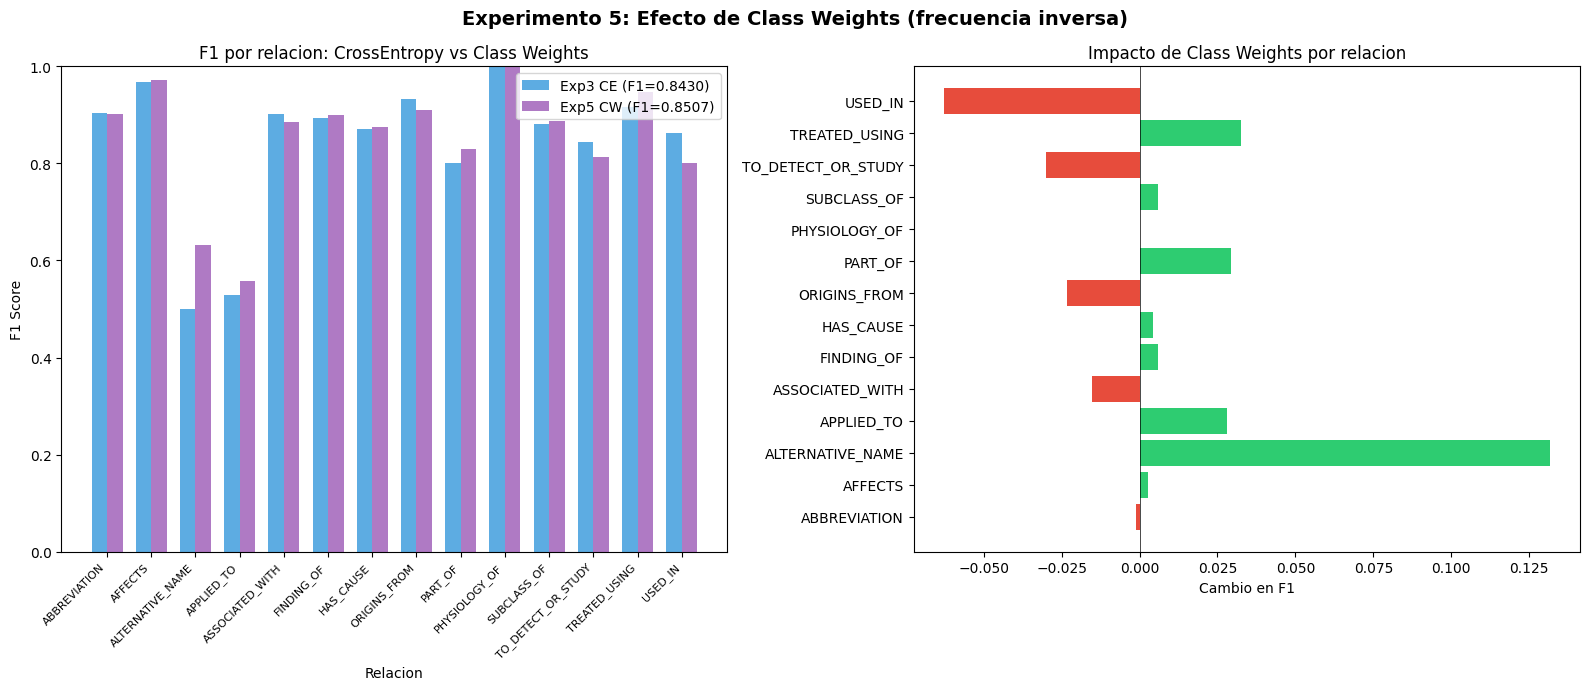

In [17]:
# Comparacion vs experimento 3: F1 por relacion
prev_results_exp3 = {
    "ABBREVIATION": 0.9032, "AFFECTS": 0.9685, "ALTERNATIVE_NAME": 0.5000,
    "APPLIED_TO": 0.5294, "ASSOCIATED_WITH": 0.9008, "FINDING_OF": 0.8929,
    "HAS_CAUSE": 0.8715, "ORIGINS_FROM": 0.9325, "PART_OF": 0.8009,
    "PHYSIOLOGY_OF": 1.0000, "SUBCLASS_OF": 0.8808, "TO_DETECT_OR_STUDY": 0.8435,
    "TREATED_USING": 0.9153, "USED_IN": 0.8627,
}

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Experimento 5: Efecto de Class Weights (frecuencia inversa)", fontsize=14, fontweight="bold")

rels_plot = [r for r in all_relations if results.get(r, {}).get("support", 0) > 0]
f1_exp3 = [prev_results_exp3.get(r, 0) for r in rels_plot]
f1_exp5 = [results[r]["f1"] for r in rels_plot]

x = np.arange(len(rels_plot))
width = 0.35

axes[0].bar(x - width/2, f1_exp3, width, label='Exp3 CE (F1=0.8430)', color='#3498db', alpha=0.8)
axes[0].bar(x + width/2, f1_exp5, width, label=f'Exp5 CW (F1={macro_f1:.4f})', color='#9b59b6', alpha=0.8)
axes[0].set_xlabel('Relacion')
axes[0].set_ylabel('F1 Score')
axes[0].set_title('F1 por relacion: CrossEntropy vs Class Weights')
axes[0].set_xticks(x)
axes[0].set_xticklabels(rels_plot, rotation=45, ha='right', fontsize=8)
axes[0].legend()
axes[0].set_ylim(0, 1)

diffs = [f1_exp5[i] - f1_exp3[i] for i in range(len(rels_plot))]
colors = ['#2ecc71' if d > 0 else '#e74c3c' for d in diffs]
axes[1].barh(rels_plot, diffs, color=colors)
axes[1].set_xlabel('Cambio en F1')
axes[1].set_title('Impacto de Class Weights por relacion')
axes[1].axvline(x=0, color='black', linewidth=0.5)

plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / f"comparacion_{EXPERIMENT_NAME}.png"), dpi=150, bbox_inches='tight')
plt.show()

## 8. Analisis de errores: han mejorado las clases minoritarias con class weights?

In [18]:
# Comparar errores del experimento 3 vs ahora
prev_errors_exp3 = {
    ("PART_OF", "SUBCLASS_OF"): 58,
    ("ALTERNATIVE_NAME", "no_relation"): 36,
    ("HAS_CAUSE", "no_relation"): 28,
    ("SUBCLASS_OF", "HAS_CAUSE"): 25,
    ("SUBCLASS_OF", "PART_OF"): 24,
    ("HAS_CAUSE", "ASSOCIATED_WITH"): 20,
    ("HAS_CAUSE", "SUBCLASS_OF"): 19,
    ("TO_DETECT_OR_STUDY", "APPLIED_TO"): 19,
    ("APPLIED_TO", "TO_DETECT_OR_STUDY"): 17,
    ("SUBCLASS_OF", "no_relation"): 14,
}

confusion_pairs = Counter()
for g, p in zip(gold_labels, pred_labels):
    if g != p:
        confusion_pairs[(g, p)] += 1

total_errors = sum(confusion_pairs.values())
print(f"Total errores: {total_errors} / {total} ({100*total_errors/total:.1f}%)")
print(f"(Exp3 tenia: 405 errores / 13.7%)")

print(f"\n{'Confusion':<55} {'Exp3':>6} {'Ahora':>6} {'Delta':>8}")
print("-" * 80)
for (g, p), prev_count in sorted(prev_errors_exp3.items(), key=lambda x: -x[1]):
    curr_count = confusion_pairs.get((g, p), 0)
    diff = curr_count - prev_count
    symbol = "MEJORA" if diff < 0 else ("PEOR" if diff > 0 else "igual")
    pair_str = f"{g} -> {p}"
    print(f"{pair_str:<55} {prev_count:>6} {curr_count:>6} {diff:>+8} ({symbol})")

# Foco en las clases problema
print(f"\n--- Foco en clases dificiles ---")
for rel in ["ALTERNATIVE_NAME", "APPLIED_TO", "PART_OF"]:
    exp3_f1 = prev_results_exp3.get(rel, 0)
    exp5_f1 = results[rel]["f1"]
    print(f"{rel}: F1 {exp3_f1:.4f} -> {exp5_f1:.4f} ({exp5_f1 - exp3_f1:+.4f})")

print(f"\nTop 10 confusiones actuales:")
print(f"{'Real':<25} {'Predicho':<25} {'Count':>6}")
print("-" * 60)
for (g, p), count in confusion_pairs.most_common(10):
    print(f"{g:<25} {p:<25} {count:>6}")

Total errores: 385 / 2967 (13.0%)
(Exp3 tenia: 405 errores / 13.7%)

Confusion                                                 Exp3  Ahora    Delta
--------------------------------------------------------------------------------
PART_OF -> SUBCLASS_OF                                      58     54       -4 (MEJORA)
ALTERNATIVE_NAME -> no_relation                             36     20      -16 (MEJORA)
HAS_CAUSE -> no_relation                                    28     20       -8 (MEJORA)
SUBCLASS_OF -> HAS_CAUSE                                    25      6      -19 (MEJORA)
SUBCLASS_OF -> PART_OF                                      24     17       -7 (MEJORA)
HAS_CAUSE -> ASSOCIATED_WITH                                20     26       +6 (PEOR)
HAS_CAUSE -> SUBCLASS_OF                                    19     37      +18 (PEOR)
TO_DETECT_OR_STUDY -> APPLIED_TO                            19     30      +11 (PEOR)
APPLIED_TO -> TO_DETECT_OR_STUDY                            17      7    

## 9. Guardar resultados

In [20]:
experiment_results = {
    "experiment": EXPERIMENT_NAME,
    "model": MODEL_NAME,
    "technique": "PubMedBERT + typed markers + neg_ratio 1:1 + class weights",
    "single_change_vs_exp3": "CrossEntropyLoss() -> CrossEntropyLoss(weight=inverse_freq)",
    "hyperparameters": {
        "max_length": MAX_LENGTH,
        "batch_size": BATCH_SIZE,
        "learning_rate": LEARNING_RATE,
        "epochs": EPOCHS,
        "warmup_steps": WARMUP_STEPS,
        "seed": SEED,
        "neg_ratio": TARGET_NEG_RATIO,
    },
    "class_weights": {rel: float(CLASS_WEIGHTS[rel2id[rel]]) for rel in rel2id},
    "training_data": {
        "n_positives": n_pos_train,
        "n_negatives": n_neg_train,
        "total": n_pos_train + n_neg_train,
        "effective_neg_ratio": n_neg_train / n_pos_train,
    },
    "results": {
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "per_relation": results,
    },
    "comparison": {
        "baseline_macro_f1": 0.6944,
        "exp1_pubmedbert_macro_f1": 0.7754,
        "exp2_typed_markers_macro_f1": 0.8078,
        "exp3_neg1_macro_f1": 0.8430,
        "exp4_focal_macro_f1": 0.8346,
        "exp5_classweights_macro_f1": macro_f1,
        "delta_vs_exp3": macro_f1 - 0.8430,
        "delta_vs_exp4": macro_f1 - 0.8346,
        "delta_vs_baseline": macro_f1 - 0.6944,
    },
    "error_analysis": {
        "total_errors": total_errors,
        "error_rate": total_errors / total,
        "top_confusions": [
            {"gold": g, "pred": p, "count": c}
            for (g, p), c in confusion_pairs.most_common(10)
        ],
    },
}

with open(RESULTS_PATH, "w") as f:
    json.dump(experiment_results, f, indent=2)

print(f"Resultados guardados en: {RESULTS_PATH}")
print(f"\n{'='*60}")
print(f"RESUMEN FINAL")
print(f"{'='*60}")
print(f"Macro F1: {macro_f1:.4f}")
print(f"Cambio vs Exp3: {macro_f1 - 0.8430:+.4f}")
print(f"Cambio vs Exp4: {macro_f1 - 0.8346:+.4f}")
print(f"Cambio vs Baseline: {macro_f1 - 0.6944:+.4f}")
if macro_f1 > 0.8430:
    print(f"\nClass Weights MEJORA el modelo vs Exp3.")
elif macro_f1 < 0.8430:
    print(f"\nClass Weights EMPEORA el modelo vs Exp3.")
else:
    print(f"\nClass Weights NO CAMBIA el modelo vs Exp3.")

Resultados guardados en: /kaggle/working/outputs/results_pubmedbert_typed_neg1_classweights.json

RESUMEN FINAL
Macro F1: 0.8507
Cambio vs Exp3: +0.0077
Cambio vs Exp4: +0.0161
Cambio vs Baseline: +0.1563

Class Weights MEJORA el modelo vs Exp3.


In [21]:
# ============================================================
# CELDA FINAL: empaquetar todos los outputs
# ============================================================
import shutil
from pathlib import Path

output_dir = Path("/kaggle/working/outputs")
zip_dest = Path("/kaggle/working/exp5_class_weights_outputs.zip")

shutil.make_archive(
    str(zip_dest).replace('.zip', ''),
    'zip',
    str(output_dir.parent),
    str(output_dir.name)
)
print(f"ZIP creado: {zip_dest}")
print(f"Tamano ZIP: {zip_dest.stat().st_size / 1e6:.1f} MB")
print()

print("Archivos en /kaggle/working/:")
for f in sorted(Path("/kaggle/working").rglob("*")):
    if f.is_file():
        print(f"  {f.relative_to('/kaggle/working')}  ({f.stat().st_size/1e6:.1f} MB)")

print()
print("=" * 60)
print(f"EXPERIMENTO 5 — CLASS WEIGHTS")
print(f"Macro F1: {macro_f1:.4f}")
print(f"Checkpoint: {CKPT_PATH.name}")
print(">>> Descarga 'exp5_class_weights_outputs.zip' desde el panel Output <<<")

ZIP creado: /kaggle/working/exp5_class_weights_outputs.zip
Tamano ZIP: 417.8 MB

Archivos en /kaggle/working/:
  .virtual_documents/__notebook_source__.ipynb  (0.0 MB)
  eng_pubmedbert_typed_neg1_classweights.pth.tar  (447.6 MB)
  exp5_class_weights_outputs.zip  (417.8 MB)
  outputs/comparacion_pubmedbert_typed_neg1_classweights.png  (0.2 MB)
  outputs/eng_dev_typed.txt  (2.5 MB)
  outputs/eng_pred_pubmedbert_typed_neg1_classweights.tsv  (0.3 MB)
  outputs/eng_pubmedbert_typed_neg1_classweights.pth.tar  (447.6 MB)
  outputs/eng_train_typed_neg1.txt  (7.1 MB)
  outputs/results_pubmedbert_typed_neg1_classweights.json  (0.0 MB)

EXPERIMENTO 5 — CLASS WEIGHTS
Macro F1: 0.8507
Checkpoint: eng_pubmedbert_typed_neg1_classweights.pth.tar
>>> Descarga 'exp5_class_weights_outputs.zip' desde el panel Output <<<


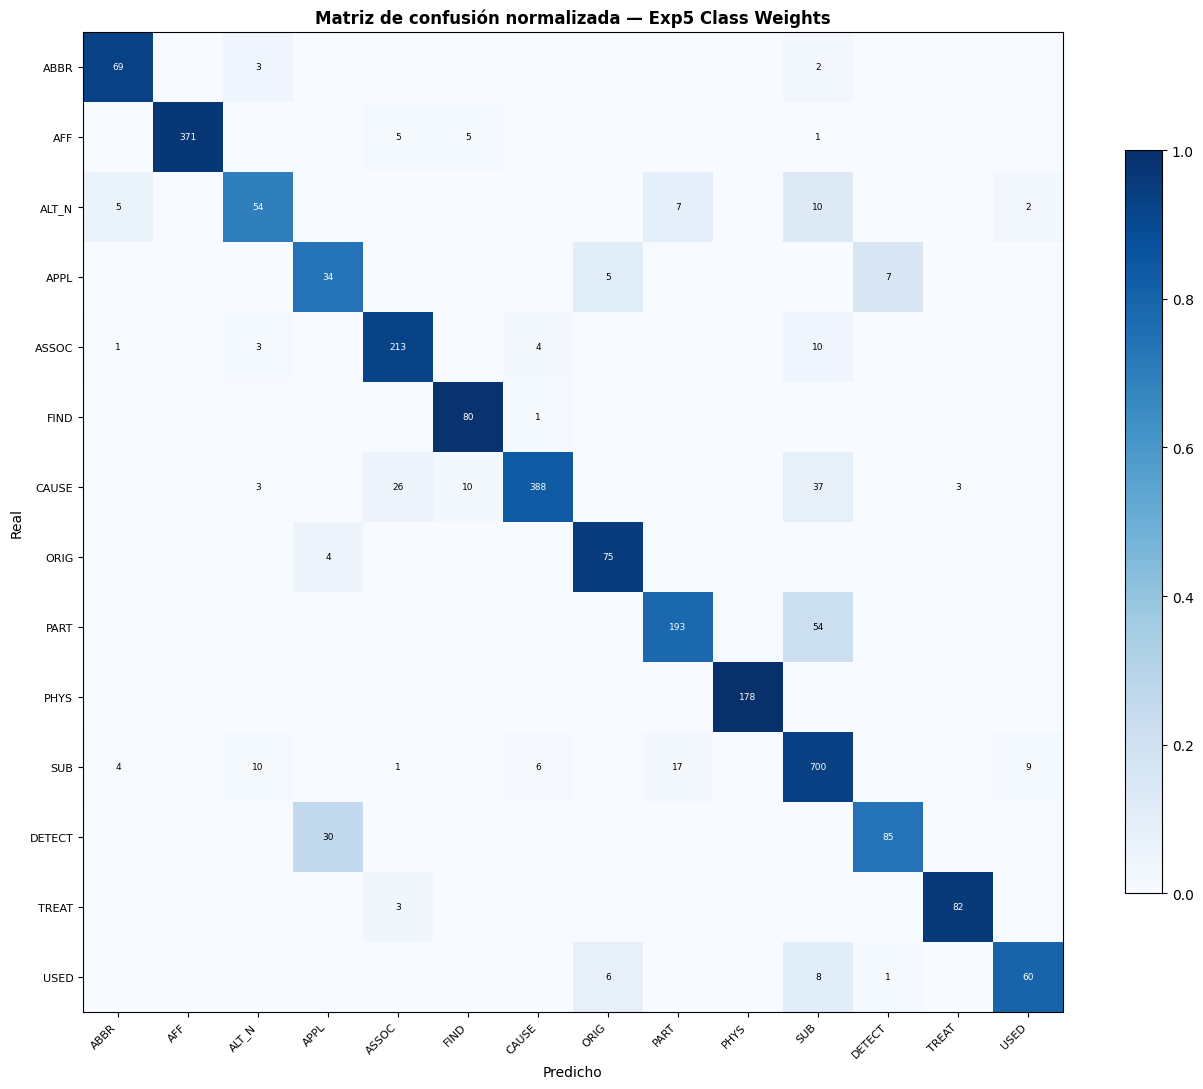

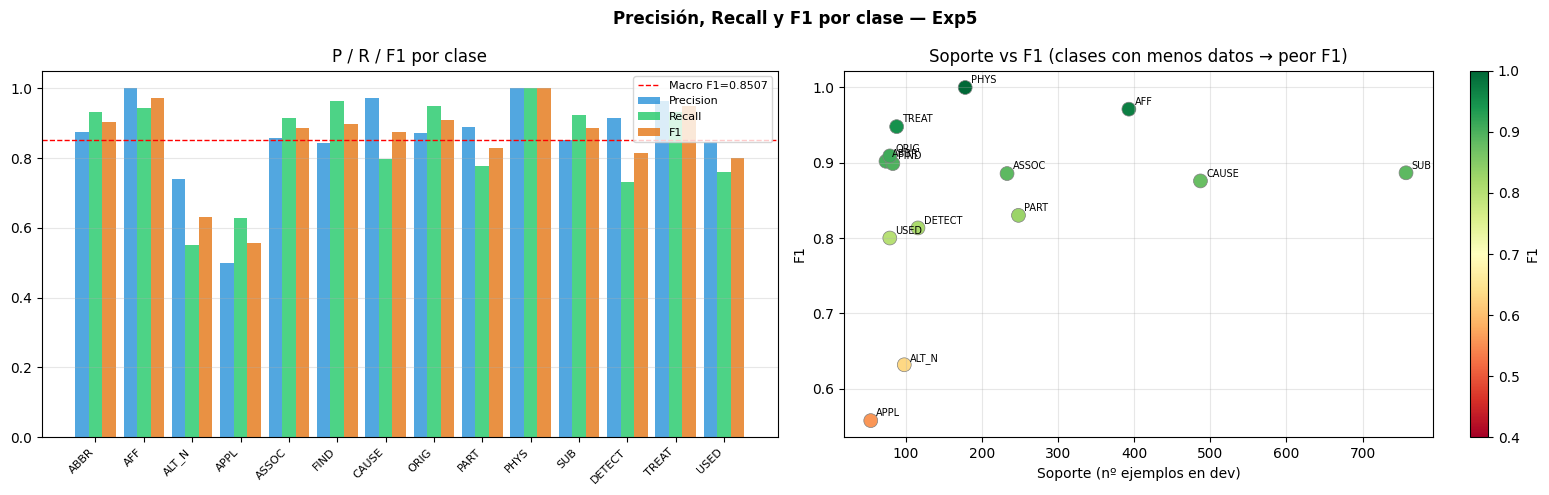

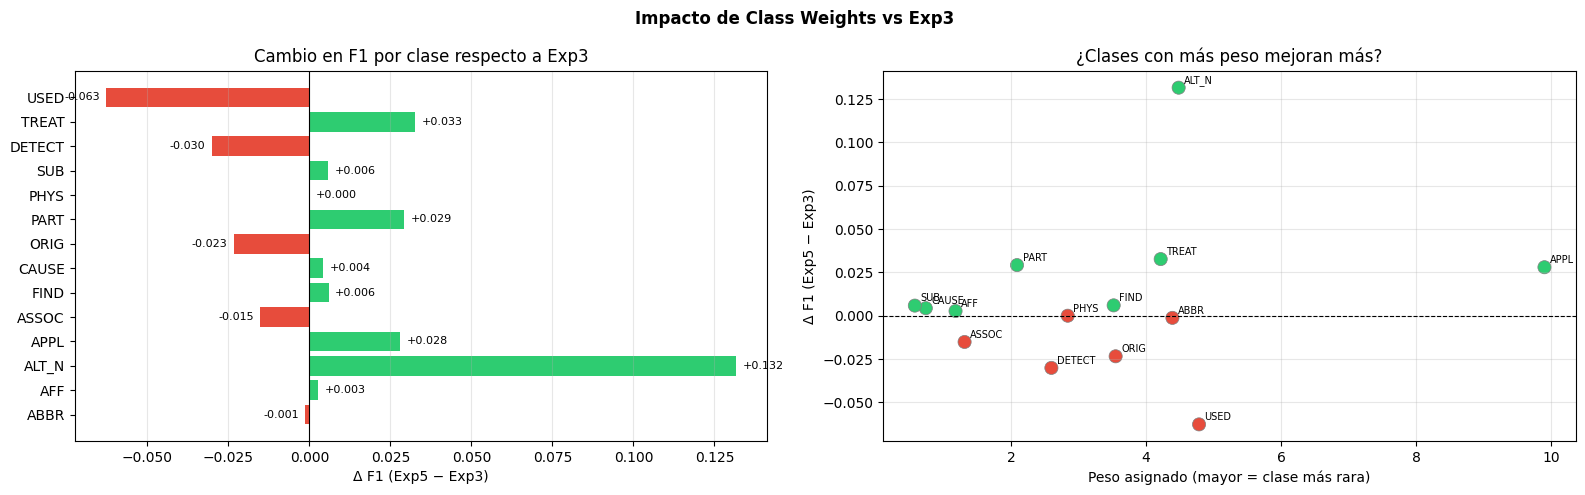

Guardadas: confusion_matrix_exp5.png | prf1_exp5.png | delta_classweights_exp5.png


In [22]:
# ============================================================
# VISUALIZACIONES EXTRA — Exp5
# ============================================================
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

RELS = [r for r in all_relations if results[r]["support"] > 0]
SHORT = {  # etiquetas cortas para los ejes
    "ABBREVIATION": "ABBR", "ALTERNATIVE_NAME": "ALT_N", "SUBCLASS_OF": "SUB",
    "PART_OF": "PART", "TREATED_USING": "TREAT", "ORIGINS_FROM": "ORIG",
    "TO_DETECT_OR_STUDY": "DETECT", "AFFECTS": "AFF", "HAS_CAUSE": "CAUSE",
    "APPLIED_TO": "APPL", "USED_IN": "USED", "ASSOCIATED_WITH": "ASSOC",
    "PHYSIOLOGY_OF": "PHYS", "FINDING_OF": "FIND", "no_relation": "NEG",
}

# ── 1. Matriz de confusión ────────────────────────────────
fig1, ax = plt.subplots(figsize=(13, 11))
cm = confusion_matrix(gold_labels, pred_labels, labels=RELS)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
plt.colorbar(im, ax=ax, fraction=0.03)
ticks = [SHORT[r] for r in RELS]
ax.set_xticks(range(len(RELS))); ax.set_xticklabels(ticks, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(RELS))); ax.set_yticklabels(ticks, fontsize=8)
ax.set_xlabel("Predicho"); ax.set_ylabel("Real")
ax.set_title("Matriz de confusión normalizada — Exp5 Class Weights", fontweight="bold")

for i in range(len(RELS)):
    for j in range(len(RELS)):
        if cm[i, j] > 0:
            color = "white" if cm_norm[i, j] > 0.5 else "black"
            ax.text(j, i, str(cm[i, j]), ha="center", va="center", fontsize=6.5, color=color)

plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / "confusion_matrix_exp5.png"), dpi=150, bbox_inches="tight")
plt.show()

# ── 2. P / R / F1 por clase + soporte ────────────────────
fig2, axes = plt.subplots(1, 2, figsize=(16, 5))
fig2.suptitle("Precisión, Recall y F1 por clase — Exp5", fontweight="bold")

x = np.arange(len(RELS))
w = 0.28
ps = [results[r]["precision"] for r in RELS]
rs = [results[r]["recall"]    for r in RELS]
fs = [results[r]["f1"]        for r in RELS]
supports = [results[r]["support"] for r in RELS]

axes[0].bar(x - w, ps, w, label="Precision", color="#3498db", alpha=0.85)
axes[0].bar(x,     rs, w, label="Recall",    color="#2ecc71", alpha=0.85)
axes[0].bar(x + w, fs, w, label="F1",        color="#e67e22", alpha=0.85)
axes[0].axhline(macro_f1, color="red", linestyle="--", linewidth=1, label=f"Macro F1={macro_f1:.4f}")
axes[0].set_xticks(x); axes[0].set_xticklabels([SHORT[r] for r in RELS], rotation=45, ha="right", fontsize=8)
axes[0].set_ylim(0, 1.05); axes[0].legend(fontsize=8); axes[0].grid(axis="y", alpha=0.3)
axes[0].set_title("P / R / F1 por clase")

# Scatter: soporte vs F1
ax2 = axes[1]
scatter = ax2.scatter(supports, fs, c=fs, cmap="RdYlGn", s=100, vmin=0.4, vmax=1.0, edgecolors="gray", linewidths=0.5)
plt.colorbar(scatter, ax=ax2, label="F1")
for r, sup, f in zip(RELS, supports, fs):
    ax2.annotate(SHORT[r], (sup, f), textcoords="offset points", xytext=(4, 3), fontsize=7)
ax2.set_xlabel("Soporte (nº ejemplos en dev)"); ax2.set_ylabel("F1")
ax2.set_title("Soporte vs F1 (clases con menos datos → peor F1)")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / "prf1_exp5.png"), dpi=150, bbox_inches="tight")
plt.show()

# ── 3. Delta F1 vs Exp3 + pesos de clase ─────────────────
fig3, axes = plt.subplots(1, 2, figsize=(16, 5))
fig3.suptitle("Impacto de Class Weights vs Exp3", fontweight="bold")

deltas = [results[r]["f1"] - prev_results_exp3.get(r, 0) for r in RELS]
colors = ["#2ecc71" if d > 0 else "#e74c3c" for d in deltas]
axes[0].barh([SHORT[r] for r in RELS], deltas, color=colors)
axes[0].axvline(0, color="black", linewidth=0.8)
axes[0].set_xlabel("Δ F1 (Exp5 − Exp3)")
axes[0].set_title("Cambio en F1 por clase respecto a Exp3")
for i, (d, r) in enumerate(zip(deltas, RELS)):
    axes[0].text(d + (0.002 if d >= 0 else -0.002), i, f"{d:+.3f}",
                 va="center", ha="left" if d >= 0 else "right", fontsize=8)
axes[0].grid(axis="x", alpha=0.3)

# Scatter: peso de clase vs Δ F1
weights = [float(CLASS_WEIGHTS[rel2id[r]]) for r in RELS]
axes[1].scatter(weights, deltas, c=["#2ecc71" if d > 0 else "#e74c3c" for d in deltas],
                s=90, edgecolors="gray", linewidths=0.5)
for r, w_, d in zip(RELS, weights, deltas):
    axes[1].annotate(SHORT[r], (w_, d), textcoords="offset points", xytext=(4, 3), fontsize=7)
axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_xlabel("Peso asignado (mayor = clase más rara)")
axes[1].set_ylabel("Δ F1 (Exp5 − Exp3)")
axes[1].set_title("¿Clases con más peso mejoran más?")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / "delta_classweights_exp5.png"), dpi=150, bbox_inches="tight")
plt.show()

print("Guardadas: confusion_matrix_exp5.png | prf1_exp5.png | delta_classweights_exp5.png")